In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = r"C:\Users\dhanv\OneDrive\Desktop\IDEAFORGE\merged_accounts.csv"
df = pd.read_csv(data)

In [8]:
df

,account_id,platform,account_age_days,has_profile_picture,is_default_avatar,bio_length,has_bio,username_digit_ratio,username_length,follower_count,following_count,is_verified,profile_completeness,posts_per_day_avg,pct_posts_duplicate_content,avg_time_between_posts_min,device_fingerprint_diversity,is_fake
0,acct_000000,Instagram,185.186136,1.0,0.0,53.837527,1,0.249402,8,127.407639,475.138474,0.0,0.642974,0.522092,0.240890,120.576277,3,0
1,acct_000001,Instagram,250.702953,1.0,0.0,73.653084,1,0.316408,10,122.857008,14.179881,0.0,0.558407,11.092488,0.311032,64.167271,3,0
2,acct_000002,Twitter,57.081761,1.0,0.0,37.178904,1,0.148344,7,26.225607,547.492497,0.0,0.527218,5.009516,0.234690,38.396072,3,0
3,acct_000003,Twitter,404.000000,1.0,0.0,174.000000,1,1.000000,9,386.000000,699.000000,1.0,0.649268,0.466667,0.910019,3085.714284,2,1
4,acct_000004,Twitter,5717.000000,1.0,0.0,155.000000,1,0.000000,13,854.716478,0.000000,0.0,0.818614,0.556103,NaN,2589.448916,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,acct_018995,Instagram,4641.000000,0.0,1.0,182.000000,1,0.000000,5,385.000000,728.000000,1.0,0.466559,0.044377,0.780746,32448.932039,4,0
18996,acct_018996,Facebook,229.962796,1.0,0.0,0.000000,0,0.089281,12,151.831451,266.452606,0.0,0.798892,4.709656,0.184459,0.614957,4,0
18997,acct_018997,Twitter,NaN,1.0,0.0,40.000000,1,0.000000,11,-0.000000,379.505692,0.0,0.693423,NaN,NaN,NaN,1,1
18998,acct_018998,Twitter,5478.000000,1.0,0.0,89.000000,1,0.166667,6,0.000000,0.000000,0.0,0.815590,-0.000000,NaN,NaN,4,0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
#Now we will plot out a graph to see which features hold the most importance
x = df.drop(columns=["account_id", "platform" , "is_fake"])  # drop target + non-numeric ID
y = df['is_fake']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
rf_clf = RandomForestClassifier()
rf_clf.fit(x_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

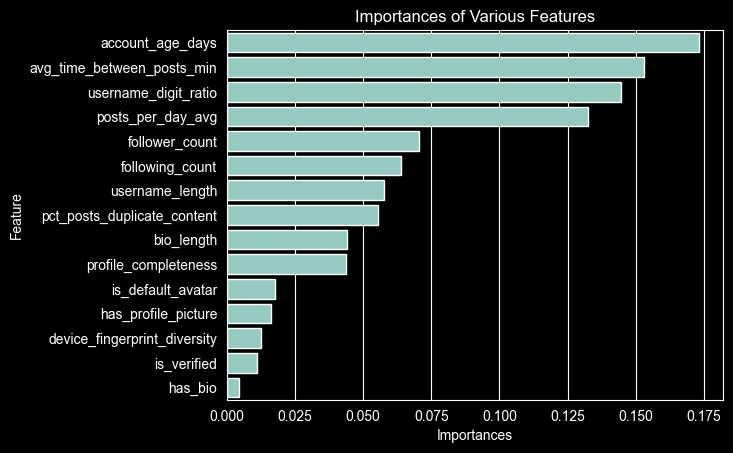

In [11]:
importances = rf_clf.feature_importances_
feature_names = x.columns
feat_imp_df = pd.DataFrame({"Feature":feature_names , "Importances":importances})
sort_imp = feat_imp_df.sort_values(by="Importances" , ascending=False)
sns.barplot(y="Feature" , x="Importances" , data=sort_imp)
plt.title("Importances of Various Features")
plt.show()

In [12]:
#Now for further insight lets also see the importances
imp = sort_imp.head(100)
print(imp)

                         Feature  Importances
0               account_age_days     0.173400
13    avg_time_between_posts_min     0.152967
5           username_digit_ratio     0.144461
11             posts_per_day_avg     0.132485
7                 follower_count     0.070603
8                following_count     0.063764
6                username_length     0.057599
12   pct_posts_duplicate_content     0.055346
3                     bio_length     0.044129
10          profile_completeness     0.043852
2              is_default_avatar     0.017479
1            has_profile_picture     0.016198
14  device_fingerprint_diversity     0.012350
9                    is_verified     0.011000
4                        has_bio     0.004365


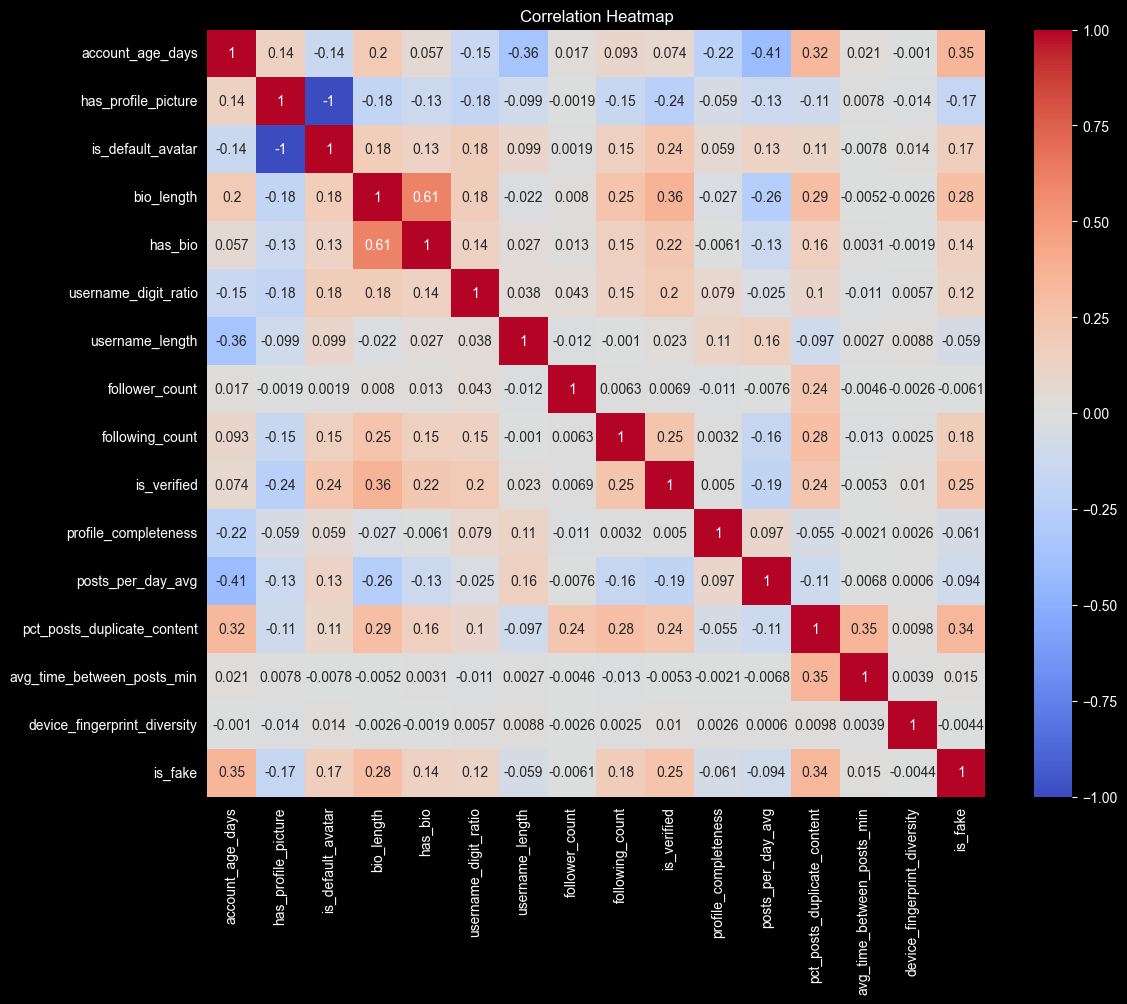

In [13]:
#Now lets plot a heatmap and see if there are any features that have same effect on the status of the account
sns.heatmap(df.corr(numeric_only=True) , annot=True , cmap="coolwarm" , ax=plt.subplots(figsize=(12,10))[1])
plt.tight_layout()
plt.title("Correlation Heatmap")
plt.show()

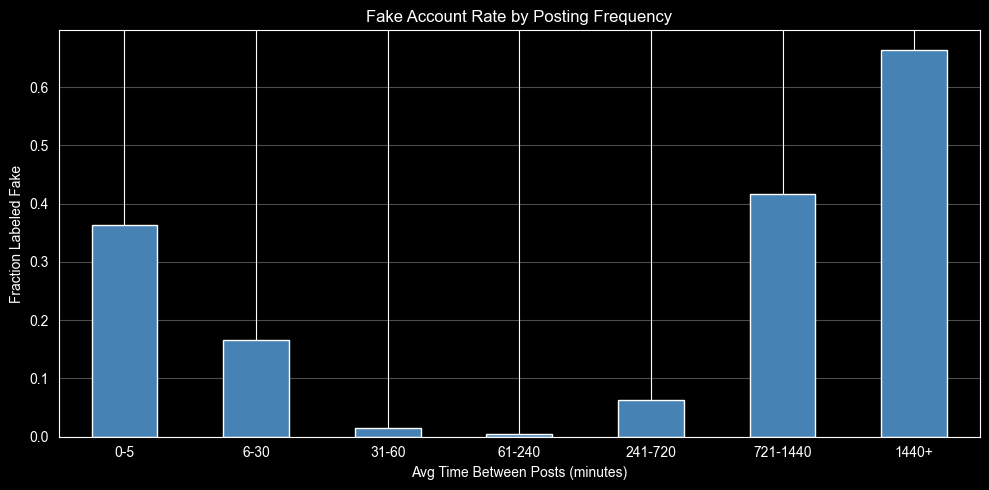

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('merged_accounts.csv')

# Bin avg time between posts into ranges (minutes)
bins = [0, 5, 30, 60, 240, 720, 1440, df['avg_time_between_posts_min'].max()]
labels = ['0-5', '6-30', '31-60', '61-240', '241-720', '721-1440', '1440+']
df['time_bucket'] = pd.cut(df['avg_time_between_posts_min'], bins=bins, labels=labels)

fake_rate = df.groupby('time_bucket', observed=True)['is_fake'].mean()

plt.figure(figsize=(10, 5))
fake_rate.plot(kind='bar', color='steelblue')
plt.xlabel('Avg Time Between Posts (minutes)')
plt.ylabel('Fraction Labeled Fake')
plt.title('Fake Account Rate by Posting Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fake_rate_by_posting_time.png')
plt.show()